# Assignment 1 - Step 1

In [108]:
#Import relevant libraries
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [109]:
# import wind CF data for 6 windfarms and cut to be 24 hours and average out

W1_data = pd.read_csv('data\data\data\scen_zone1.csv')
W1_CF = W1_data.iloc[1:25, 1:].mean(axis=1)

W2_data = pd.read_csv('data\data\data\scen_zone2.csv')
W2_CF = W2_data.iloc[1:25, 1:].mean(axis=1)

W3_data = pd.read_csv('data\data\data\scen_zone3.csv')
W3_CF = W3_data.iloc[1:25, 1:].mean(axis=1)

W4_data = pd.read_csv('data\data\data\scen_zone4.csv')
W4_CF = W4_data.iloc[1:25, 1:].mean(axis=1)

W5_data = pd.read_csv('data\data\data\scen_zone5.csv')
W5_CF = W5_data.iloc[1:25, 1:].mean(axis=1)

W6_data = pd.read_csv('data\data\data\scen_zone6.csv')
W6_CF = W6_data.iloc[1:25, 1:].mean(axis=1)


In [110]:
#create variable list with length of 12 for genrators Pg_i where i is the generator number
Pg = [f"Pg_{i}" for i in range(1, 13)] #MW
Pw = [f"Pw_{i}" for i in range(1,7)] #MW 

VARIABLES = Pg + Pw
#create a list of the cost coefficients for each variable
Generation_price = [13.32,13.32,20.7,20.93,26.11,10.52,10.52,6.02,5.47,0,10.52,10.89, 0 ,0 ,0 ,0 ,0, 0] #$/MWh
#writes a list that converts the cost coefficient to this form objective_coeff = {'Pg_1': 13.32, 'Pg_2': 13.32, ...}
objective_coeff = {VARIABLES[i]: Generation_price[i] for i in range(len(VARIABLES))}


#write the load percentages for each node
Load_percentage = [3.8,3.4,6.3,2.6,2.5,4.8,4.4,6,6.1,6.8,9.3,6.8,11.1,3.5,11.7,6.4,4.5]
#multiply the load percentage with the total load to get the actual load in MW
hour1_load = 1775.835 #MW
#hour1_load = 2650.5 Max demand check
Load = [hour1_load * (i / 100) for i in Load_percentage] #MW


#create a random price list with 17 values between 106$/MWh and 166$/MWh (from nordpool)and sort it in descending order
#change prices for clarity in the plot
Randonm_prices = np.random.uniform(106, 166, 17)
Demand_price= np.array(sorted(Randonm_prices, reverse=True))-85 #$/MWh #CHANGE AFTER WIND INCORPORATION

# create capacity factor variables from winddata


#create a upper bound for the production variables
Generator_UB = [152,152,350,591,60,155,155,400,400,300,310,350] #MW
Wind_UB = np.array([W1_CF[1], W2_CF[1], W3_CF[1], W4_CF[1],W5_CF[1],W6_CF[1]])*200
Constraints_rhs = Generator_UB + Wind_UB.tolist()
#create constraints sense list with 12 values of GRB.LESS_EQUAL
constraints_sense = [GRB.LESS_EQUAL] * 18




In [111]:
#Create model
model = gp.Model("Copperplate_singlehour")

In [112]:
#Add variables
variables = {v: model.addVar(lb=0, name=f'variable {v}') for v in VARIABLES}

In [113]:
# Set objective function and optimization direction of the Gurobi model
objective = gp.quicksum(Demand_price[v] * Load[v] for v in range(len(Load))) - gp.quicksum(objective_coeff[v] * variables[v] for v in VARIABLES)
model.setObjective(objective, GRB.MAXIMIZE)


In [114]:
# Add constraints to the Gurobi model

#Add balance constraint to the Gurobi model that ensures that the total load is equal to the total generation
Balance_constraint = [
    model.addLConstr(
        gp.quicksum(Load[i] for i in range(len(Demand_price)))-gp.quicksum(variables[v] for v in variables), GRB.EQUAL, 0,
        name=f"Balance_constraint" 
    )
    
]

#Add boundary constraints to the Gurobi model that ensures that the generation of each generator is less than or equal to its upper bound
Boundary_constraints = {}

for v, rhs in zip(VARIABLES, Constraints_rhs):
    Boundary_constraints[v] = model.addLConstr(
        variables[v],
        GRB.LESS_EQUAL,
        rhs
    )

In [115]:
model.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 19 rows, 18 columns and 36 nonzeros (Max)
Model fingerprint: 0x0ac2e477
Model has 11 linear objective coefficients and an objective constant of -9.1789745813059242e+04
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e+00, 3e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+01, 2e+03]

Presolve removed 18 rows and 9 columns
Presolve time: 0.01s
Presolved: 1 rows, 9 columns, 9 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    9.1789746e+04   9.075994e+01   0.000000e+00      0s
       1    8.7638747e+04   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.02 seconds (0.00 work units)
Optimal objective  8.763874724e+04


In [116]:
# check status and print results
if model.status == GRB.OPTIMAL:
    print(f"Optimal objective: {model.ObjVal}")
    for i in VARIABLES:
        print(f"Optimal dispatch of generator {i}: {variables[i].X}")
    print(f"Optimal Dual value of load constraint: {Balance_constraint[0].Pi}")
    for i in VARIABLES:
        print(f"Dual value of capacity constraint for generator {i}: {Boundary_constraints[i].Pi}")
else:
    print(f"optimization of {model.ModelName} was not successful")

Optimal objective: 87638.7472351631
Optimal dispatch of generator Pg_1: 0.0
Optimal dispatch of generator Pg_2: 0.0
Optimal dispatch of generator Pg_3: 0.0
Optimal dispatch of generator Pg_4: 0.0
Optimal dispatch of generator Pg_5: 0.0
Optimal dispatch of generator Pg_6: 0.0
Optimal dispatch of generator Pg_7: 0.0
Optimal dispatch of generator Pg_8: 326.0794979893931
Optimal dispatch of generator Pg_9: 400.0
Optimal dispatch of generator Pg_10: 300.0
Optimal dispatch of generator Pg_11: 0.0
Optimal dispatch of generator Pg_12: 0.0
Optimal dispatch of generator Pw_1: 118.54163745949499
Optimal dispatch of generator Pw_2: 139.63512850803707
Optimal dispatch of generator Pw_3: 135.50204551881356
Optimal dispatch of generator Pw_4: 102.78490618913705
Optimal dispatch of generator Pw_5: 131.59804421716413
Optimal dispatch of generator Pw_6: 121.69374011796054
Optimal Dual value of load constraint: 6.02
Dual value of capacity constraint for generator Pg_1: 0.0
Dual value of capacity constrai

In [117]:
#printing the market clearing price
print(f"Under a uniform pricing scheme\n the market clearing price: {Balance_constraint[0].Pi} $/MWh")

#the total operating cost of the system
total_cost = sum(objective_coeff[v] * variables[v].X for v in VARIABLES)
print(f"Total operating cost of the system: {total_cost:.2f} $")

#The social welfare of the system
social_welfare = model.ObjVal
print(f"Social welfare of the system: {social_welfare:.2f} $")

#the profit of each producer
for i in VARIABLES:
    profit = (Balance_constraint[0].Pi - objective_coeff[i]) * variables[i].X
    print(f"Profit of generator {i}: {profit:.2f} $")

#the utility of each consumer
for i in range(len(Load)):
    utility = (Demand_price[i] - Balance_constraint[0].Pi) * Load[i]
    print(f"Utility of consumer {i}: {utility:.2f} $")



Under a uniform pricing scheme
 the market clearing price: 6.02 $/MWh
Total operating cost of the system: 4151.00 $
Social welfare of the system: 87638.75 $
Profit of generator Pg_1: -0.00 $
Profit of generator Pg_2: -0.00 $
Profit of generator Pg_3: -0.00 $
Profit of generator Pg_4: -0.00 $
Profit of generator Pg_5: -0.00 $
Profit of generator Pg_6: -0.00 $
Profit of generator Pg_7: -0.00 $
Profit of generator Pg_8: 0.00 $
Profit of generator Pg_9: 220.00 $
Profit of generator Pg_10: 1806.00 $
Profit of generator Pg_11: -0.00 $
Profit of generator Pg_12: -0.00 $
Profit of generator Pw_1: 713.62 $
Profit of generator Pw_2: 840.60 $
Profit of generator Pw_3: 815.72 $
Profit of generator Pw_4: 618.77 $
Profit of generator Pw_5: 792.22 $
Profit of generator Pw_6: 732.60 $
Utility of consumer 0: 5003.49 $
Utility of consumer 1: 4412.95 $
Utility of consumer 2: 7941.21 $
Utility of consumer 3: 3269.83 $
Utility of consumer 4: 3076.53 $
Utility of consumer 5: 4827.84 $
Utility of consumer 6:

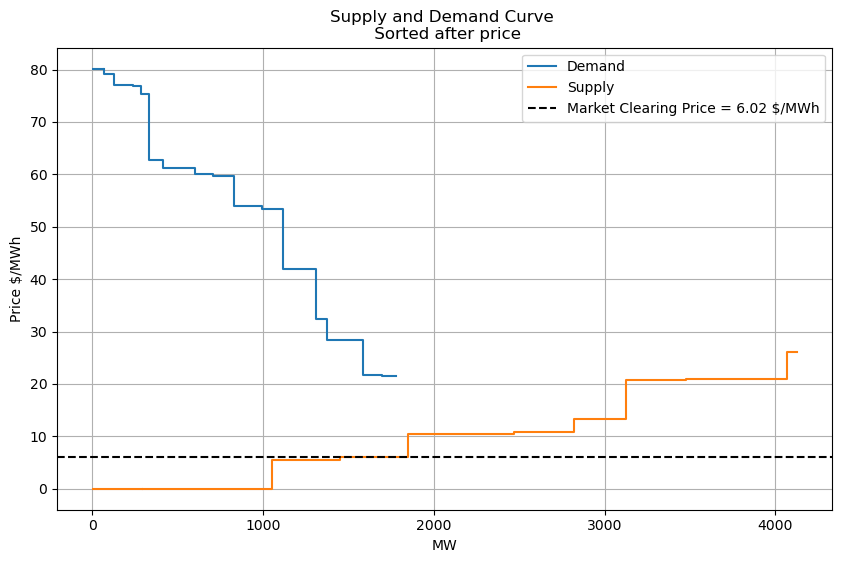

In [118]:
#sorting data for plotting the supply and demand curve
supply_data = [
    (Generation_price[i], VARIABLES[i], variables[VARIABLES[i]].X, Constraints_rhs[i])
    for i in range(len(VARIABLES))
]
supply_data_sorted = sorted(supply_data, key=lambda x: x[0])
sorted_prices = [x[0] for x in supply_data_sorted]
sorted_dispatch = [x[3] for x in supply_data_sorted]
cumulative_supply = np.cumsum(sorted_dispatch)



#plot the supply and demand curve
plt.figure(figsize=(10, 6))
plt.step(np.cumsum(Load), Demand_price, label='Demand')
plt.step(cumulative_supply, sorted_prices, label='Supply')

#plot purely for aestetic reason
plt.hlines(y=0, xmin=0, xmax=cumulative_supply[0], color='tab:orange')
plt.hlines(y=Demand_price[0], xmin=0, xmax=Load[0], color='tab:blue')

#plot marketclearing price
plt.axhline(y=Balance_constraint[0].Pi, color='black', linestyle='--', label=f'Market Clearing Price = {Balance_constraint[0].Pi} $/MWh')

#final plotting details
plt.xlabel('MW')
plt.ylabel('Price $/MWh')
plt.title('Supply and Demand Curve \n Sorted after price')
plt.legend()
plt.grid()
plt.show()





